In [3]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
import pandas as pd


In [4]:
from src.preference_factors.build_datasets import build_EBC_dataset 


In [5]:
df_EBC_monthly_returns, df_EBC_monthly_weights, df_EBC_monthly_beta_contributions = build_EBC_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly")

/Users/santi/PycharmProjects/Invesco_Research_Project/src/preference_factors/build_EBC.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_weights = full_weights.fillna(0.0)


In [6]:
from src.preference_factors.build_datasets import build_all_dataset, build_returns_dataset
from src.FamaMacBeth.betas import compute_rolling_betas
from src.FamaMacBeth.pipeline import run_full_factor_pipeline

merged_df, full_merged_df = build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

ebc = merged_df["EBC"]
cw_ebc = merged_df["CW-EBC"]


/Users/santi/PycharmProjects/Invesco_Research_Project/src/preference_factors/build_EBC.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_weights = full_weights.fillna(0.0)


In [ ]:
print("helo")

In [14]:
asset_returns = build_returns_dataset("sp500_returns_monthly_with_tickers.csv", frequency="monthly")
factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()
factor_returns.columns = ["EBC", "CW-EBC"]

asset_returns, factor_returns = asset_returns.align(factor_returns, join="inner", axis=0)

betas_ebc = compute_rolling_betas(asset_returns, ebc, rolling_window=36, min_obs=10)
betas_cw_ebc = compute_rolling_betas(asset_returns, cw_ebc, rolling_window=36, min_obs=10)

beta1_df = betas_ebc.to_frame()
beta2_df = betas_cw_ebc.to_frame()

results = run_full_factor_pipeline(
    beta1_df=beta1_df,
    beta2_df=beta2_df,
    sp500=asset_returns,
    EBC=factor_returns["EBC"],
    Cap_EBC=factor_returns["CW-EBC"],
    n_q1=3,
    n_q2=3,
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC",
)

results["mean_grid"]


IndexError: tuple index out of range

In [ ]:
df_EBC_monthly_returns

,EBC_returns_monthly
date,
1973-01,-0.031484
1973-02,-0.038560
1973-03,-0.012266
1973-04,-0.032555
1973-05,-0.041462
...,...
2024-08,0.032232
2024-09,0.016421
2024-10,-0.017517


In [ ]:
df_EBC_monthly_weights

,A,AA,AAF,AAL,AAP,AAPL,ABA,ABBV,ABC,ABI,...,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZMH,ZRN,ZTS,ZY
date,,,,,,,,,,,,,,,,,,,,,
1973-01,0.001871,0.001703,0.0,0.000000,0.0,0.000000,0.001380,0.000000,0.001386,0.0,...,0.0,0.001666,0.000000,0.000000,0.001379,0.0,0.0,0.0,0.000000,0.0
1973-02,0.001994,0.001803,0.0,0.000000,0.0,0.000000,0.001337,0.000000,0.001425,0.0,...,0.0,0.001678,0.000000,0.000000,0.001282,0.0,0.0,0.0,0.000000,0.0
1973-03,0.002319,0.001840,0.0,0.000000,0.0,0.000000,0.001322,0.000000,0.001253,0.0,...,0.0,0.001660,0.000000,0.000000,0.001253,0.0,0.0,0.0,0.000000,0.0
1973-04,0.002281,0.001795,0.0,0.000000,0.0,0.000000,0.001270,0.000000,0.001205,0.0,...,0.0,0.001578,0.000000,0.000000,0.001241,0.0,0.0,0.0,0.000000,0.0
1973-05,0.001950,0.001842,0.0,0.000000,0.0,0.000000,0.001082,0.000000,0.001386,0.0,...,0.0,0.001696,0.000000,0.000000,0.001196,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08,0.001626,0.000000,0.0,0.001489,0.0,0.001743,0.000000,0.003533,0.000000,0.0,...,0.0,0.000000,0.002628,0.001137,0.000000,0.0,0.0,0.0,0.001917,0.0
2024-09,0.001703,0.000000,0.0,0.001579,0.0,0.001742,0.000000,0.003435,0.000000,0.0,...,0.0,0.000000,0.002494,0.001287,0.000000,0.0,0.0,0.0,0.001897,0.0
2024-10,0.001685,0.000000,0.0,0.000000,0.0,0.001689,0.000000,0.003705,0.000000,0.0,...,0.0,0.000000,0.002491,0.001227,0.000000,0.0,0.0,0.0,0.001939,0.0


In [ ]:
import src.analysis.basic_analytics as ba

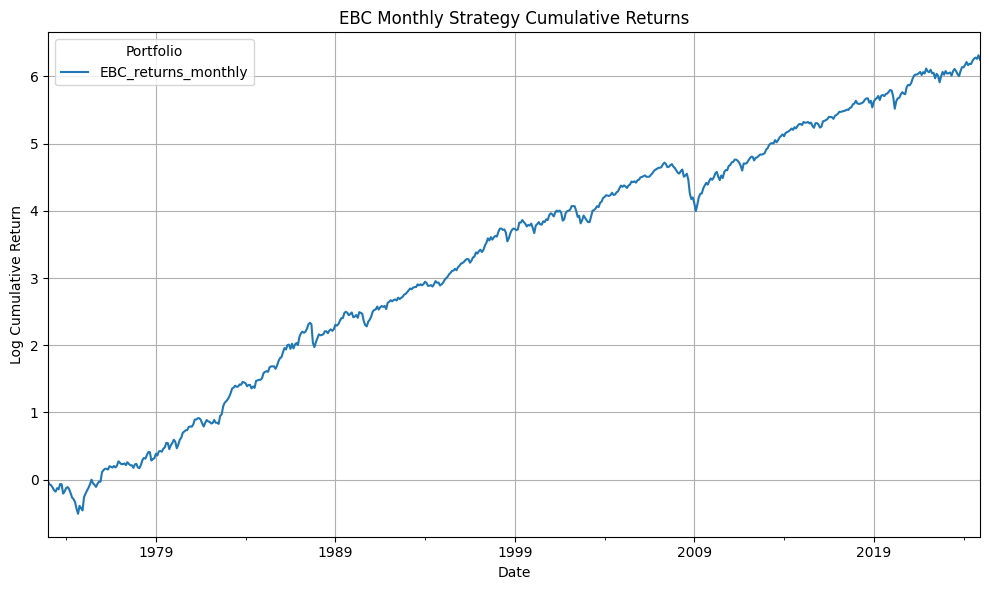

In [ ]:
ba.plot_cumulative_returns(df_EBC_monthly_returns, columns= "EBC_returns_monthly", title="EBC Monthly Strategy Cumulative Returns")

In [ ]:
df_EBC_monthly_beta_contributions

,A,AA,AAF,AAL,AAP,AAPL,ABA,ABBV,ABC,ABI,...,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZMH,ZRN,ZTS,ZY
date,,,,,,,,,,,,,,,,,,,,,
1973-01,0.002092,0.002179,NaN,NaN,NaN,NaN,0.002123,NaN,0.002121,NaN,...,NaN,0.002188,NaN,NaN,0.002123,NaN,NaN,NaN,NaN,NaN
1973-02,0.002186,0.002262,NaN,NaN,NaN,NaN,0.002253,NaN,0.002274,NaN,...,NaN,0.002224,NaN,NaN,0.002219,NaN,NaN,NaN,NaN,NaN
1973-03,0.002207,0.002244,NaN,NaN,NaN,NaN,0.002239,NaN,0.002181,NaN,...,NaN,0.002203,NaN,NaN,0.002181,NaN,NaN,NaN,NaN,NaN
1973-04,0.002166,0.00216,NaN,NaN,NaN,NaN,0.002164,NaN,0.002141,NaN,...,NaN,0.002139,NaN,NaN,0.002152,NaN,NaN,NaN,NaN,NaN
1973-05,0.002071,0.002094,NaN,NaN,NaN,NaN,0.002238,NaN,0.002175,NaN,...,NaN,0.002147,NaN,NaN,0.002126,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08,0.001987,NaN,NaN,0.001955,NaN,0.002054,NaN,0.001584,NaN,NaN,...,NaN,NaN,0.001868,0.001912,NaN,NaN,NaN,NaN,0.001934,NaN
2024-09,0.002029,NaN,NaN,0.002089,NaN,0.002055,NaN,0.001547,NaN,NaN,...,NaN,NaN,0.001843,0.00215,NaN,NaN,NaN,NaN,0.001924,NaN
2024-10,0.001973,NaN,NaN,NaN,NaN,0.001966,NaN,0.001448,NaN,NaN,...,NaN,NaN,0.00184,0.002036,NaN,NaN,NaN,NaN,0.001976,NaN
